# 02 · Baseline y evaluación honesta

Ejecutar todas las celdas en orden. Datos históricos y simulaciones educativas; no representan una aplicación financiera real.

In [1]:
from pathlib import Path
import sys, os
os.environ["EVIDENTLY_DO_NOT_TRACK"]="1"
base=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"_config.yml").exists())
project=base/"actividad_3/proyecto_inicial"
sys.path.insert(0,str(project/"src"))
os.environ["BANK_ROOT"]=str(project)
import numpy as np, pandas as pd
from bank_ops.data import load, partitions
from bank_ops.config import FEATURES, SEED
from bank_ops.model import pipeline, metrics
data=load(); train,validation,test=partitions(data)


## Ajuste exclusivo en entrenamiento
Scaler y encoder se ajustan dentro del Pipeline. El umbral 0.25 es ilustrativo.

In [2]:
estimator=pipeline();estimator.fit(train[FEATURES],(train.y=="yes").astype(int))
probability=estimator.predict_proba(validation[FEATURES])[:,1]
result=metrics((validation.y=="yes").astype(int),probability)
display(pd.Series({k:v for k,v in result.items() if k!="confusion_matrix"}))
display(pd.DataFrame(result["confusion_matrix"],index=["real no","real yes"],columns=["pred no","pred yes"]))

n                    9042.000000
prevalence              0.117894
average_precision       0.168429
roc_auc                 0.624764
precision               0.000000
recall                  0.000000
f1                      0.000000
brier                   0.104156
threshold               0.250000
dtype: float64

,pred no,pred yes
real no,7972,4
real yes,1066,0


## Sensibilidad al umbral
Esta exploración usa validación. No seleccionar umbrales con prueba final.

,threshold,precision,recall,f1
0,0.05,0.147544,0.797373,0.249011
1,0.10,0.177349,0.378987,0.241627
2,0.15,0.236994,0.038462,0.066182
3,0.25,0.000000,0.000000,0.000000
4,0.50,0.000000,0.000000,0.000000


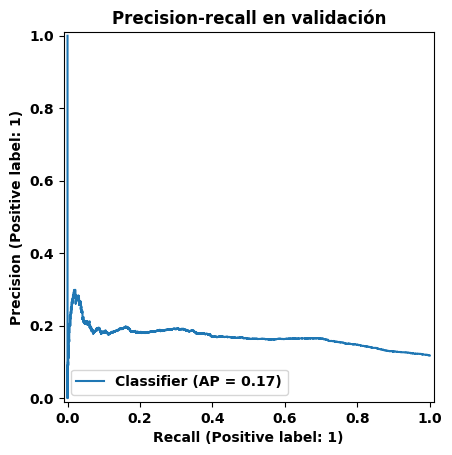

In [3]:
rows=[metrics((validation.y=="yes").astype(int),probability,t) for t in [.05,.1,.15,.25,.5]]
display(pd.DataFrame(rows)[["threshold","precision","recall","f1"]])
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt
PrecisionRecallDisplay.from_predictions((validation.y=="yes").astype(int),probability)
plt.title("Precision-recall en validación");plt.show()

## Interpretación
Si recall es cero, no ocultar el resultado. ¿Qué significa para falsos negativos? ¿Qué costos necesitaría para elegir un umbral? Comparar AP con prevalencia.

## Profundización avanzada

Experimentos de estudio opcionales. No añaden entregables ni resuelven las tareas obligatorias del proyecto inicial.

### Hipótesis 1: el umbral cambia capacidad y utilidad, no el ranking
Todas las decisiones exploratorias se realizan en validation. Valor de un verdadero positivo = 10 unidades; costo de cada selección = 2. Son supuestos didácticos, no ingresos causales ni tarifas reales. No se modifica el umbral del artefacto servido.

,umbral,TP,FP,FN,TN,seleccion,precision,recall,utilidad_hipotetica
0,0.030,946,6330,120,1646,0.804689,0.130016,0.887430,-5092
1,0.050,850,4911,216,3065,0.637138,0.147544,0.797373,-3022
2,0.075,722,3654,344,4322,0.483964,0.164991,0.677298,-1532
3,0.100,404,1874,662,6102,0.251935,0.177349,0.378987,-516
4,0.150,41,132,1025,7844,0.019133,0.236994,0.038462,64
5,0.200,4,24,1062,7952,0.003097,0.142857,0.003752,-16
6,0.250,0,4,1066,7972,0.000442,0.000000,0.000000,-8
7,0.500,0,0,1066,7976,0.000000,0.000000,0.000000,0


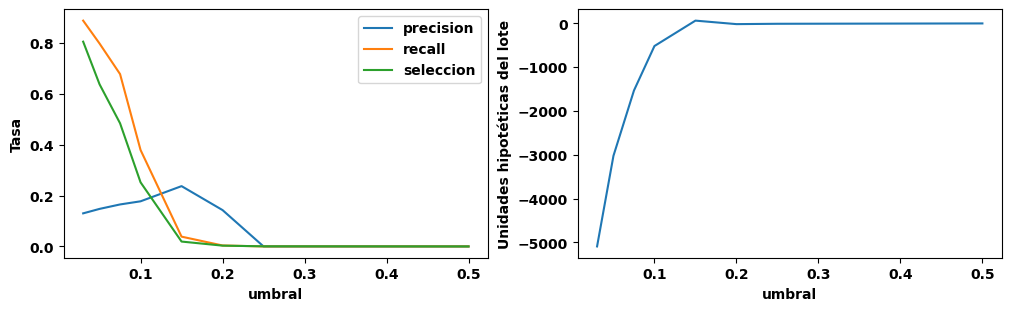

In [4]:
truth=(validation.y=="yes").astype(int).to_numpy()
table=[]
for threshold in [.03,.05,.075,.10,.15,.20,.25,.5]:
    row=metrics(truth,probability,threshold)
    tn,fp,fn,tp=np.asarray(row["confusion_matrix"]).ravel()
    table.append({"umbral":threshold,"TP":tp,"FP":fp,"FN":fn,"TN":tn,
                  "seleccion":(tp+fp)/len(truth),"precision":row["precision"],
                  "recall":row["recall"],"utilidad_hipotetica":10*tp-2*(tp+fp)})
policy=pd.DataFrame(table);display(policy)
assert policy[["TP","FP","FN","TN"]].sum(axis=1).eq(len(truth)).all()
assert (policy.seleccion.diff().dropna()<=0).all()
fig,axes=plt.subplots(1,2,figsize=(10,3),constrained_layout=True)
policy.plot(x="umbral",y=["precision","recall","seleccion"],ax=axes[0])
policy.plot(x="umbral",y="utilidad_hipotetica",ax=axes[1],legend=False)
axes[0].set_ylabel("Tasa");axes[1].set_ylabel("Unidades hipotéticas del lote")
plt.show()

**Interpretación:** identifique cuántas personas selecciona cada política y qué cambia si el valor supuesto baja de 10 a 5. No es correcto elegir un umbral con test y seguir llamando independiente a ese test. AP y ROC AUC se mantienen al cambiar solo el umbral porque las probabilidades originales no cambian.

### Hipótesis 2: conservar orden no conserva calidad probabilística
Compararemos las probabilidades originales con su cubo, una transformación monótona. Se estudia el efecto; no se recomienda esa transformación como calibrador. El Brier depende de más que calibración y debe interpretarse junto con otras métricas.

,score,AUC,Brier
0,original,0.624764,0.104156
1,cubo,0.624764,0.117647


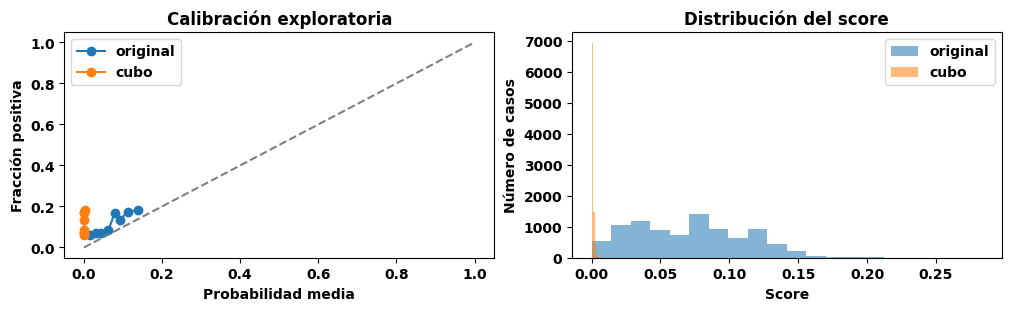

,n,positivos,probabilidad,observado
bin,,,,
"(-0.000999999738, 0.0252]",1131,69,0.015093,0.061008
"(0.0252, 0.0358]",1130,80,0.029803,0.070796
"(0.0358, 0.052]",1130,78,0.043550,0.069027
"(0.052, 0.0729]",1130,95,0.062723,0.084071
"(0.0729, 0.0831]",1130,189,0.078444,0.167257
"(0.0831, 0.1]",1130,152,0.091430,0.134513
"(0.1, 0.12]",1130,196,0.112082,0.173451
"(0.12, 0.283]",1131,207,0.138386,0.183024


In [5]:
from sklearn.metrics import roc_auc_score,brier_score_loss
from sklearn.calibration import calibration_curve
transformed=probability**3
display(pd.DataFrame([{"score":name,"AUC":roc_auc_score(truth,p),"Brier":brier_score_loss(truth,p)}
                      for name,p in [("original",probability),("cubo",transformed)]]))
assert np.isclose(roc_auc_score(truth,probability),roc_auc_score(truth,transformed))
fig,axes=plt.subplots(1,2,figsize=(10,3),constrained_layout=True)
for name,p in [("original",probability),("cubo",transformed)]:
    observed,predicted=calibration_curve(truth,p,n_bins=8,strategy="quantile")
    axes[0].plot(predicted,observed,marker="o",label=name)
    axes[1].hist(p,bins=20,alpha=.55,label=name)
axes[0].plot([0,1],[0,1],"--",color="gray")
axes[0].set(xlabel="Probabilidad media",ylabel="Fracción positiva",title="Calibración exploratoria")
axes[1].set(xlabel="Score",ylabel="Número de casos",title="Distribución del score")
for ax in axes:ax.legend()
plt.show()
bins=pd.qcut(probability,q=8,duplicates="drop")
calibration_table=pd.DataFrame({"bin":bins,"p":probability,"y":truth}).groupby("bin",observed=True).agg(n=("y","size"),positivos=("y","sum"),probabilidad=("p","mean"),observado=("y","mean"))
display(calibration_table)

**Lectura y límites:** las agrupaciones por cuantiles intentan repartir volumen, pero empates pueden reducir su número. La curva resume grupos, no probabilidades individuales. Compare n y positivos antes de interpretar un punto. Este notebook no ajusta un calibrador ni usa test; una recalibración real necesitaría datos de ajuste separados y su propia evaluación.